<a href="https://colab.research.google.com/github/Teixeiras15-collab/Atividades/blob/main/Atividade_Pr%C3%A1tica_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Configuração do Ambiente e Base de Dados**
Execute o bloco abaixo no Google Colab ou Jupyter para importar as bibliotecas e gerar o DataFrame sintético da atividade:


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração de estilo global do Seaborn
sns.set_theme(style="whitegrid", palette="muted")

# Geração de dados sintéticos
np.random.seed(101)
n = 300

dados = {
    'idade': np.random.normal(35, 10, n).astype(int),
    'plano': np.random.choice(['Gratuito', 'Básico', 'Pro'], n, p=[0.5, 0.3, 0.2]),
    'tempo_uso_horas': np.random.uniform(1, 50, n),
    'bugs_reportados': np.random.poisson(2, n),
    'satisfacao': np.random.randint(1, 11, n)
}

df_sistema = pd.DataFrame(dados)

# Ajustando regras de negócio sintéticas para gerar correlações visuais
df_sistema.loc[df_sistema['plano'] == 'Pro', 'tempo_uso_horas'] += 15
df_sistema.loc[df_sistema['plano'] == 'Pro', 'satisfacao'] += 2
df_sistema['satisfacao'] = df_sistema['satisfacao'] - (df_sistema['bugs_reportados'] * 0.5)
df_sistema['satisfacao'] = df_sistema['satisfacao'].clip(1, 10).astype(int)
df_sistema['idade'] = df_sistema['idade'].clip(18, 70)

### **2.1 Contagem de Usuários por Tipo de Plano**

Vamos visualizar a contagem de usuários para cada tipo de plano (Gratuito, Básico, Pro) usando um gráfico de barras. As barras serão ordenadas pela frequência para facilitar a comparação.

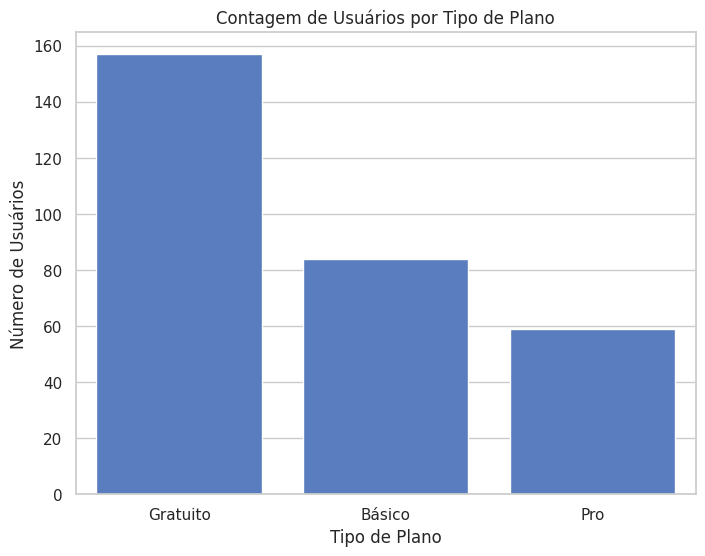

In [2]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df_sistema, x='plano', order=df_sistema['plano'].value_counts().index)
plt.title('Contagem de Usuários por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Número de Usuários')
plt.show()

### **2.2 Distribuição da Idade dos Usuários**

Agora, vamos analisar a distribuição da idade dos usuários utilizando um histograma. Para uma visualização mais suave da densidade, adicionaremos também a Curva de Densidade de Kernel (KDE).

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_sistema['idade'], kde=True, bins=20)
plt.title('Distribuição da Idade dos Usuários')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

### **3. Distribuição do Tempo de Uso por Tipo de Plano**

Vamos criar um boxplot para visualizar como o tempo de uso em horas se distribui entre os diferentes tipos de plano. Isso nos ajudará a identificar se há variações significativas no uso da plataforma dependendo do plano do usuário.

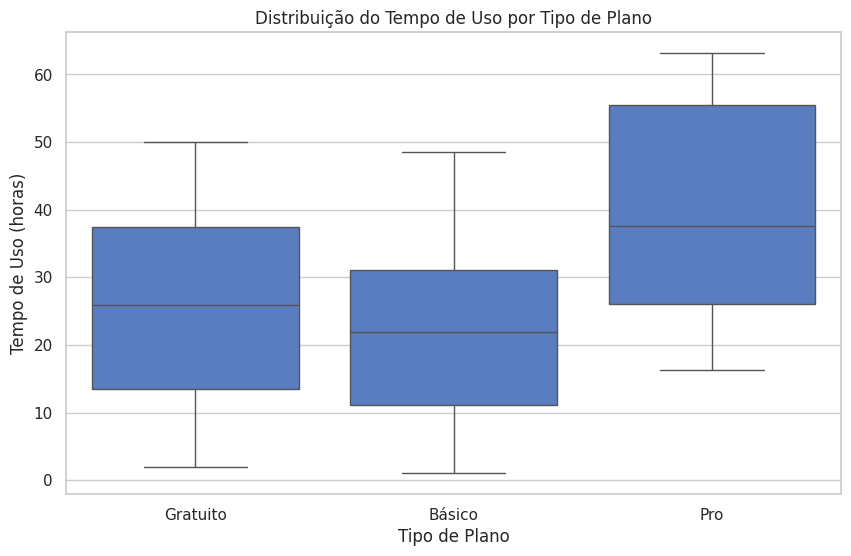

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_sistema, x='plano', y='tempo_uso_horas', order=['Gratuito', 'Básico', 'Pro'])
plt.title('Distribuição do Tempo de Uso por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Tempo de Uso (horas)')
plt.show()

### **4. Distribuição da Satisfação por Tipo de Plano**

Para entender a densidade das notas de satisfação dadas pelos clientes de cada plano, utilizaremos um violinplot. Este gráfico é útil para visualizar não apenas a mediana, mas também a distribuição completa dos dados.

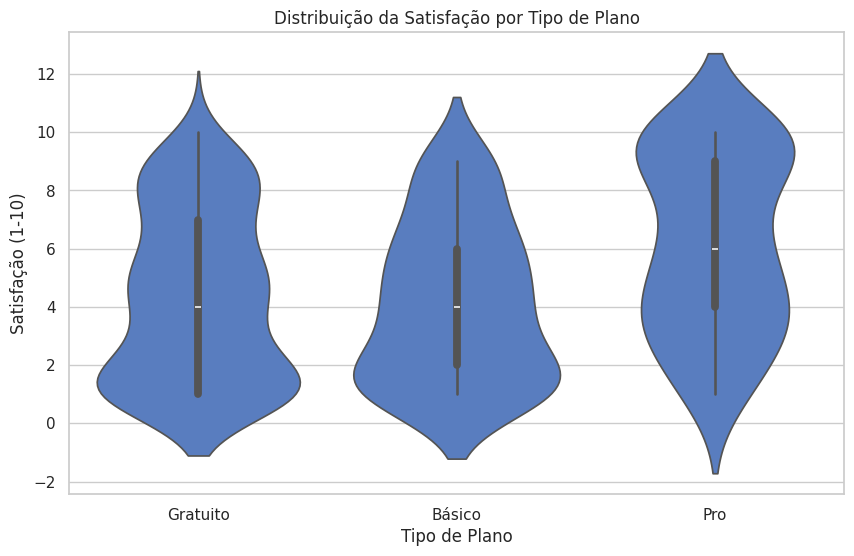

In [5]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_sistema, x='plano', y='satisfacao', order=['Gratuito', 'Básico', 'Pro'])
plt.title('Distribuição da Satisfação por Tipo de Plano')
plt.xlabel('Tipo de Plano')
plt.ylabel('Satisfação (1-10)')
plt.show()

### **5. Relação entre Tempo de Uso e Satisfação por Plano e Bugs Reportados**

Vamos investigar a relação entre o tempo de uso (`tempo_uso_horas`) e a satisfação (`satisfacao`) dos usuários. Para adicionar mais contexto, utilizaremos o tipo de plano (`plano`) como diferenciador de cores (`hue`) e a quantidade de bugs reportados (`bugs_reportados`) para variar o tamanho dos pontos (`size`). Isso nos permitirá visualizar padrões complexos de uso, satisfação e problemas reportados, segmentados por plano.

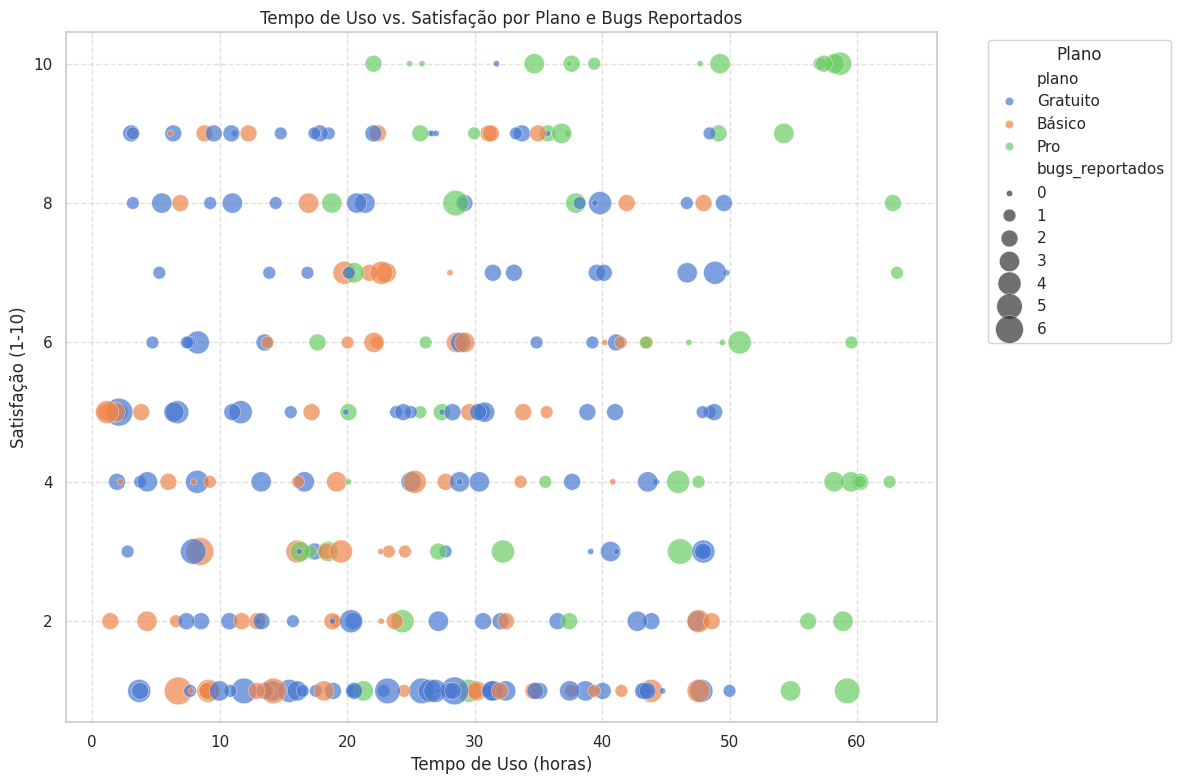

In [6]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_sistema,
    x='tempo_uso_horas',
    y='satisfacao',
    hue='plano',
    size='bugs_reportados',
    sizes=(20, 400), # Define a range for marker sizes
    alpha=0.7
)
plt.title('Tempo de Uso vs. Satisfação por Plano e Bugs Reportados')
plt.xlabel('Tempo de Uso (horas)')
plt.ylabel('Satisfação (1-10)')
plt.legend(title='Plano', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **6. Matriz de Correlação de Pearson para Variáveis Numéricas**

Para entender as relações lineares entre as variáveis numéricas, calcularemos a matriz de correlação de Pearson. Em seguida, visualizaremos essa matriz usando um heatmap, com anotações para mostrar os valores exatos de correlação e uma paleta de cores divergente para destacar correlações positivas e negativas.

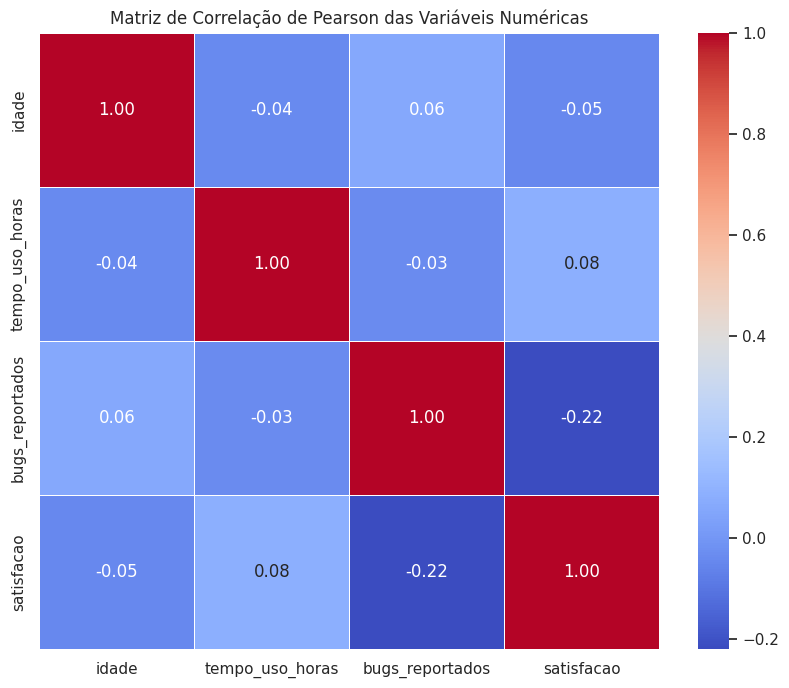

In [7]:
# Selecionar apenas variáveis numéricas
# Excluímos 'plano' porque é categórica e 'bugs_reportados' já foi usado para tamanho no scatterplot
# Mas 'bugs_reportados' é numérico, então incluímos para correlação.
# Iremos incluir idade, tempo_uso_horas, bugs_reportados, e satisfacao
numerical_df = df_sistema[['idade', 'tempo_uso_horas', 'bugs_reportados', 'satisfacao']]

# Calcular a matriz de correlação de Pearson
correlation_matrix = numerical_df.corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,      # Mostrar os valores de correlação na matriz
    cmap='coolwarm', # Paleta de cores divergente
    fmt='.2f',       # Formatar os números com duas casas decimais
    linewidths=0.5   # Adicionar linhas entre as células
)
plt.title('Matriz de Correlação de Pearson das Variáveis Numéricas')
plt.show()

### **7. (Bônus) Pairplot para Análise Multivariada**

Para uma visão geral das distribuições e relações bivariadas entre `tempo_uso_horas`, `bugs_reportados` e `satisfacao`, geraremos um pairplot. O parâmetro `hue` será utilizado para colorir os pontos de acordo com o tipo de plano, permitindo identificar como as relações variam entre os diferentes planos.

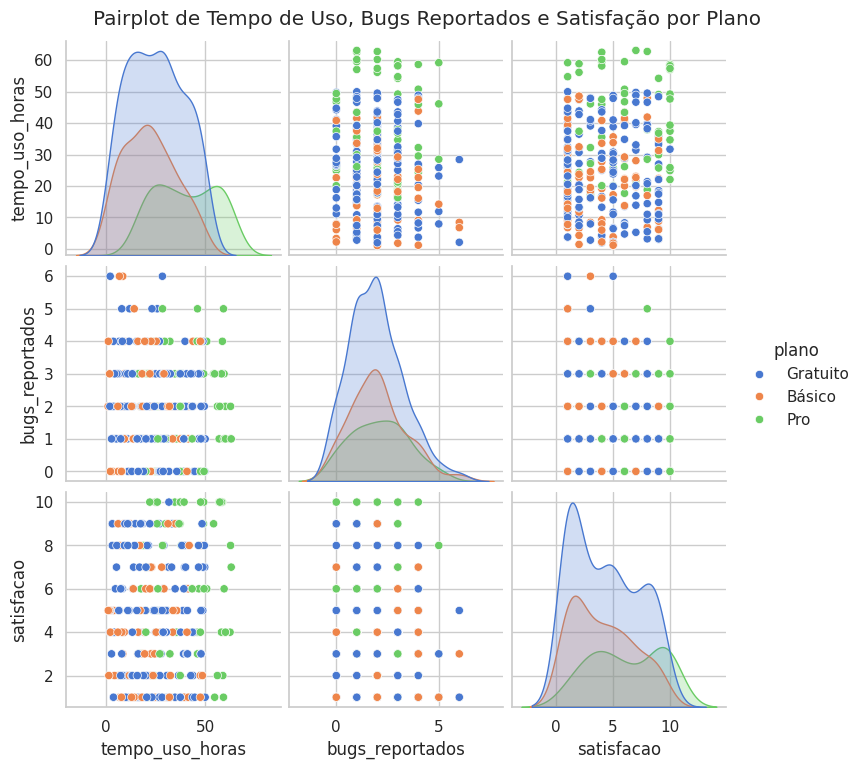

In [8]:
sns.pairplot(df_sistema, vars=['tempo_uso_horas', 'bugs_reportados', 'satisfacao'], hue='plano', palette='muted')
plt.suptitle('Pairplot de Tempo de Uso, Bugs Reportados e Satisfação por Plano', y=1.02) # Ajusta o título para não sobrepor
plt.show()